In [65]:
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt

### Colonia de Hormigas

In [ ]:
class ColoniaHormigas:
    def __init__(self, matriz_distancias):
        self.matriz_D = matriz_distancias         # matriz de distancias
        self.matriz_t = None                      # matriz de fenemonas

        # la diagonal de la matriz de distancia es cero, por lo que la división nos da infinito
        with np.errstate(divide='ignore'):
            self.matriz_n = 1.0 / self.matriz_D   # 1 / matriz de distancias
            self.matriz_n[self.matriz_n == np.inf] = 0  # la diagonal es 0

    def experimento(self, alpha, beta, p, Q, n, t0, iteraciones_max=200, iter_no_mejora=30, metodo='global'):
        # inicializacion de la matriz de fenemonas
        self.matriz_t = np.zeros_like(self.matriz_D, dtype=np.float32)
        self.matriz_t += np.random.uniform(0, t0)

        # algoritmo principal
        cantidad_ciudades = self.matriz_D.shape[0]
        i_actual = 0
        i_sin_mejora = 0
        mejor_f_global = np.inf
        mejor_camino_global = []

        while i_actual <= iteraciones_max and i_sin_mejora <= iter_no_mejora:

            # inicializacion de las hormigas (ciudad 1)
            hormigas = []
            for i in range(n):
                hormigas.append([0])        # lista de n hormigas, donde cada hormiga tiene su lista de recorrido

            # hacer los recorridos cerrados
            for hormiga in hormigas:
                while len(hormiga) < cantidad_ciudades:
                    ciudad_actual = hormiga[-1]
                    nueva_ciudad = self.seleccionar_siguiente(ciudad_actual, hormiga, alpha, beta)
                    hormiga.append(nueva_ciudad)
                
                hormiga.append(0) # volver a la ciudad 1

            # calcular el costo
            f = []
            for hormiga in hormigas:
                distancia_total = 0
                # sumamos la distancia entre cada par (i, j) en el camino
                for k in range(len(hormiga) - 1):
                    distancia_total += self.matriz_D[hormiga[k], hormiga[k+1]]
                f.append(distancia_total)
            

            # vemos si mejoramos para cortar
            indice_mejor = np.argmin(f)
            mejor_iteracion = f[indice_mejor]

            if mejor_iteracion < mejor_f_global:
                mejor_f_global = mejor_iteracion
                mejor_camino_global = hormigas[indice_mejor][:]
                i_sin_mejora = 0
            else:
                i_sin_mejora += 1

            # actualizacion de la matriz de feromonas
            # evaporación: las feromonas pierden un poco de intensidad
            self.matriz_t *= (1 - p)

            # deposito: las hormigas dejan su rastro
            for h in range(len(hormigas)):
                camino = hormigas[h]
                costo_total = f[h]
                self.actualizar_matriz(camino, costo_total, Q, metodo)
        
            i_actual += 1

        return mejor_f_global, mejor_camino_global
            
    def seleccionar_siguiente(self, i, visitados, alpha, beta):
        n = self.matriz_D.shape[0]
        # ciudades que NO visito
        permitidos = []
        for j in range(n):
              if j not in visitados:
                    permitidos.append(j)
        
        # calculamos el numerador para cada opción
        atractivo = []
        for j in permitidos:
            val = (self.matriz_t[i, j] ** alpha) * (self.matriz_n[i, j] ** beta)
            atractivo.append(val)
        
        atractivo = np.nan_to_num(atractivo, nan=0.0, posinf=1e100) # para que no de error
        
        # normalizamos para obtener probabilidades
        suma_atractivo = sum(atractivo)
        if suma_atractivo == 0 or np.isnan(suma_atractivo):
            # si no hay informacion, probabilidad equitativa para todos
            probs = [1.0 / len(permitidos)] * len(permitidos)
        else:
            probs = []
            for a in atractivo:
                probs.append(a/suma_atractivo)
        
        # elegimos aleatoriamente
        elegido = np.random.choice(permitidos, p=probs)
        return elegido
    
    def actualizar_matriz(self, camino, costo_total, Q, metodo):
        for k in range(len(camino) - 1):
            i, j = camino[k], camino[k+1]
            
            # calculamos el incremento delta según el método
            if metodo == 'global':
                delta = Q / costo_total         # depende de la calidad de todo el recorrido
            elif metodo == 'local':
                delta = Q / self.matriz_D[i, j] # depende solo de la distancia de ese tramo
            elif metodo == 'constante':
                delta = Q                       # valor fijo
            else:
                delta = 0
        
        # sumamos la feromona al tramo (y al inverso por simetría)
        self.matriz_t[i, j] += delta
        self.matriz_t[j, i] += delta

#### Uso y búsqueda de hiperparámetros

In [ ]:
def realizar_comparacion(colonia, param_nombre, valores, repeticiones=10):
    # parámetros fijos base
    params = {'alpha': 1.5, 'beta': 5.0, 
            'rho': 0.5, 'Q': 50, 
            'n': 20, 't0': 0.1, 
            'metodo': 'global'}

    print(f"{'Valor':>10} | {'Media':>10} | {'Desvío':>10} | {'Min':>10} | {'Max':>10} | {'Tiempo (s)':>10}")
    
    for val in valores:
        params[param_nombre] = val
        costos = []
        tiempos = []
        
        for i in range(repeticiones):
            np.random.seed(i)  # seteamos semilla para reproducibilidad en cada repetición
            
            inicio = time.time()
            mejor_costo, _ = colonia.experimento(alpha=params['alpha'], beta=params['beta'], p=params['rho'], 
                                                Q=params['Q'], n=params['n'], t0=params['t0'], metodo=params['metodo'])
            fin = time.time()
            
            costos.append(mejor_costo)
            tiempos.append(fin - inicio)
        
        # estadísticas
        media = np.mean(costos)
        desvio = np.std(costos)
        minimo = np.min(costos)
        maximo = np.max(costos)
        t_promedio = np.mean(tiempos)
        
        print(f"{val:10} | {media:10.2f} | {desvio:10.2f} | {minimo:10.2f} | {maximo:10.2f} | {t_promedio:10.4f}")

In [ ]:
df = pd.read_csv('gr17.csv', header=None)
distancias = df.values

colonia = ColoniaHormigas(distancias)

In [ ]:
# alpha
valores_alpha = [0.5, 1.0, 1.5, 2.0]
realizar_comparacion(colonia, 'alpha', valores_alpha)

In [ ]:
# beta
valores_beta = [1, 2, 5, 10]
realizar_comparacion(colonia, 'beta', valores_beta)

In [ ]:
# rho
valores_rho = [0.05, 0.1, 0.2, 0.5]
realizar_comparacion(colonia, 'rho', valores_rho)

In [ ]:
# metodo
valores_metodo = ['global', 'local', 'constante']
realizar_comparacion(colonia, 'metodo', valores_metodo)

#### Tabla comparativa de rho y método

In [ ]:
tasas_evaporacion = [0.05, 0.1, 0.2, 0.5]
metodos = ['global', 'local', 'constante']
corridas_por_config = 5

colonia = ColoniaHormigas(distancias)
resultados = []

for p in tasas_evaporacion:
    for m in metodos:
        tiempos = []
        costos = []
        
        for _ in range(corridas_por_config):
            inicio = time.time()
            mejor_f, _ = colonia.experimento(alpha=1.5, beta=5.0, p=p, Q=50, n=15, t0=0.1, metodo=m)
            fin = time.time()
            
            tiempos.append(fin - inicio)
            costos.append(mejor_f)
        
        resultados.append({
            'Evaporación (p)': p,
            'Método': m,
            'Tiempo Promedio (s)': np.mean(tiempos),
            'Costo Promedio (Dist)': np.mean(costos)
        })


df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

### Algoritmo Genético

In [ ]:
class AlgoritmoGenetico:
    def __init__(self, matriz_distancias):
        self.matriz_D = matriz_distancias          # matriz de distancias
        self.cantidad_ciudades = matriz_distancias.shape[0]

    def experimento(self, n, p_m, iteraciones_max=200, iter_no_mejora=30, k_torneo=3):
        # inicializacion de la poblacion
        poblacion = []
        for i in range(n):
            individuo = list(np.random.permutation(self.cantidad_ciudades))   # cada individuo es una permutacion aleatoria de las ciudades
            poblacion.append(individuo)

        # algoritmo principal
        i_actual = 0
        i_sin_mejora = 0
        mejor_f_global = np.inf
        mejor_camino_global = []

        while i_actual <= iteraciones_max and i_sin_mejora <= iter_no_mejora:
            
            # calcular el costo de la poblacion actual
            f = []
            for individuo in poblacion:
                distancia_total = self.calcular_fitness(individuo)
                f.append(distancia_total)
            
            # vemos si mejoramos para el criterio de parada
            indice_mejor = np.argmin(f)
            mejor_iteracion = f[indice_mejor]

            if mejor_iteracion < mejor_f_global:
                mejor_f_global = mejor_iteracion
                mejor_camino_global = poblacion[indice_mejor][:]
                i_sin_mejora = 0
            else:
                i_sin_mejora += 1

            # generacion de la nueva poblacion (evolucion)
            nueva_poblacion = []
            
            # mantenemos al mejor
            nueva_poblacion.append(poblacion[indice_mejor])

            while len(nueva_poblacion) < n:
                # seleccion: por torneo
                padre1 = self.seleccion_torneo(poblacion, f, k_torneo)
                padre2 = self.seleccion_torneo(poblacion, f, k_torneo)

                # cruza: orden (OX)
                hijo = self.cruza_ox(padre1, padre2)

                # mutacion: intercambio aleatorio (swap)
                hijo = self.mutacion_swap(hijo, p_m)
                
                nueva_poblacion.append(hijo)

            poblacion = nueva_poblacion
            i_actual += 1

        return mejor_f_global, mejor_camino_global

    def calcular_fitness(self, camino):
        distancia_total = 0
        for k in range(len(camino) - 1):
            distancia_total += self.matriz_D[camino[k], camino[k+1]]

        # sumar el regreso a la ciudad inicial
        distancia_total += self.matriz_D[camino[-1], camino[0]]
        return distancia_total

    def seleccion_torneo(self, poblacion, f, k):
        # elegimos k soluciones al azar y gana la de menor distancia
        indices_soluciones = random.sample(range(len(poblacion)), k)
        mejor_solucion = indices_soluciones[0]
        
        for idx in indices_soluciones:
            if f[idx] < f[mejor_solucion]:
                mejor_solucion = idx
        
        return poblacion[mejor_solucion]

    def cruza_ox(self, p1, p2):
        # OX para no repetir ciudades
        a, b = sorted(random.sample(range(self.cantidad_ciudades), 2))
        hijo = [None] * self.cantidad_ciudades
        
        # copiar segmento del primer padre
        hijo[a:b] = p1[a:b]
        
        # rellenar con ciudades del segundo padre en el orden que aparecen
        relleno = []
        for ciudad in p2:
            if ciudad not in hijo:
                relleno.append(ciudad)

        pos_vacias = []
        for i, x in enumerate(hijo):
            if x is None:
                pos_vacias.append(i)
        
        for i, ciudad in zip(pos_vacias, relleno):
            hijo[i] = ciudad
            
        return hijo

    def mutacion_swap(self, camino, p_m):
        # se intercambian dos posiciones con probabilidad p_m
        if random.random() < p_m:
            i, j = random.sample(range(len(camino)), 2)
            camino[i], camino[j] = camino[j], camino[i]
        return camino

#### Uso y búsqueda de hiperparámetros

In [ ]:
def realizar_comparacion_evolutivo(algoritmo, param_nombre, valores, repeticiones=10):
    # parámetros fijos base
    params = {'n': 100, 'p_m': 0.1, 'k_torneo': 3}

    print(f"{'Valor':>10} | {'Media':>10} | {'Desvío':>10} | {'Min':>10} | {'Max':>10} | {'Tiempo (s)':>10}")
    
    for val in valores:
        params[param_nombre] = val
        costos = []
        tiempos = []
        
        for i in range(repeticiones):
            np.random.seed(i)  # seteamos semilla para reproducibilidad en cada repetición
            
            inicio = time.time()
            mejor_costo, _ = algoritmo.experimento(n=params['n'], p_m=params['p_m'], k_torneo=params['k_torneo'])
            fin = time.time()
            
            costos.append(mejor_costo)
            tiempos.append(fin - inicio)
        
        # estadísticas
        media = np.mean(costos)
        desvio = np.std(costos)
        minimo = np.min(costos)
        maximo = np.max(costos)
        t_promedio = np.mean(tiempos)
        
        print(f"{val:10} | {media:10.2f} | {desvio:10.2f} | {minimo:10.2f} | {maximo:10.2f} | {t_promedio:10.4f}")

In [ ]:
df = pd.read_csv('gr17.csv', header=None)
distancias = df.values

algoritmo = AlgoritmoGenetico(distancias)

In [ ]:
# probabilidad
valores_p_m = [0.1, 0.2, 0.3]
realizar_comparacion_evolutivo(algoritmo, 'p_m', valores_p_m)

In [ ]:
# k_torneo
valores_k_torneo = [3, 5, 7]
realizar_comparacion_evolutivo(algoritmo, 'k_torneo', valores_k_torneo)

### Comparación de algoritmos

In [85]:
df = pd.read_csv('gr17.csv', header=None)
distancias = df.values

colonia = ColoniaHormigas(distancias)
algoritmo = AlgoritmoGenetico(distancias)

resultados_colonia = []
resultados_ag = []
tiempos_colonia = []
tiempos_ag = []

for seed in range(1, 31):
    np.random.seed(seed)
    
    inicio_c = time.time()
    mejor_f_colonia, _ = colonia.experimento(n=20, iteraciones_max=250, iter_no_mejora=40, alpha=1.5, beta=5.0, p=0.5, Q=50, t0=0.1, metodo='global')
    fin_c = time.time()
    
    inicio_a = time.time()
    mejor_f_ag, _ = algoritmo.experimento(n=100, iteraciones_max=50, iter_no_mejora=10, p_m=0.1, k_torneo=3)
    fin_a = time.time()
    
    resultados_colonia.append(mejor_f_colonia)
    resultados_ag.append(mejor_f_ag)

    tiempos_colonia.append(fin_c - inicio_c)
    tiempos_ag.append(fin_a - inicio_a)

In [88]:
def calcular_estadisticas(resultados_fitness):
    data = np.array(resultados_fitness)
    
    media = np.mean(data)
    mediana = np.median(data)
    minimo = np.min(data)
    maximo = np.max(data)
    std = np.std(data) 

    cv = std / np.abs(media) if media != 0 else 0
    
    return [media, mediana, minimo, maximo, std, cv]

# métricas
estadisticas_colonia = calcular_estadisticas(resultados_colonia)
estadisticas_ag = calcular_estadisticas(resultados_ag)

# formato y tabla
titulos = ["Algoritmo", "Media", "Mediana", "Mín", "Máx", "Std", "CV"]
filas = [
    ["Hormigas "] + [f"{s:.2f}" for s in estadisticas_colonia],
    ["Algoritmo"] + [f"{s:.2f}" for s in estadisticas_ag]
]


print("| Algoritmo |  Media  | Mediana |   Mín   |   Máx   |  Std  |  CV  |")
print(f"|{'-' * 11}|{'-' * 9}|{'-' * 9}|{'-' * 9}|{'-' * 9}|{'-' * 7}|{'-' * 6}|")
for i in filas:
    print(f"| {' | '.join(i)} |")

| Algoritmo |  Media  | Mediana |   Mín   |   Máx   |  Std  |  CV  |
|-----------|---------|---------|---------|---------|-------|------|
| Hormigas  | 2138.80 | 2149.00 | 2085.00 | 2149.00 | 20.72 | 0.01 |
| Algoritmo | 2152.93 | 2158.00 | 2085.00 | 2232.00 | 43.55 | 0.02 |


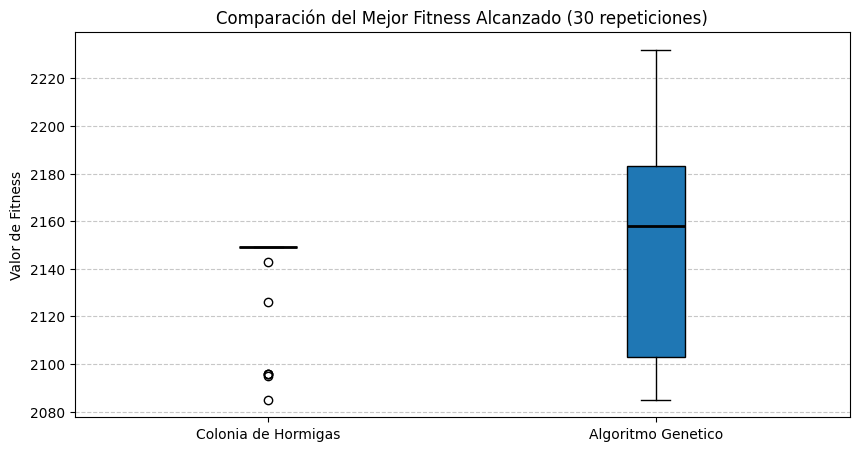

In [89]:
plt.figure(figsize=(10, 5))
box = plt.boxplot([resultados_colonia, resultados_ag], patch_artist=True, tick_labels=['Colonia de Hormigas', 'Algoritmo Genetico'], medianprops=dict(color='black', linewidth=2))

plt.title('Comparación del Mejor Fitness Alcanzado (30 repeticiones)')
plt.ylabel('Valor de Fitness')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

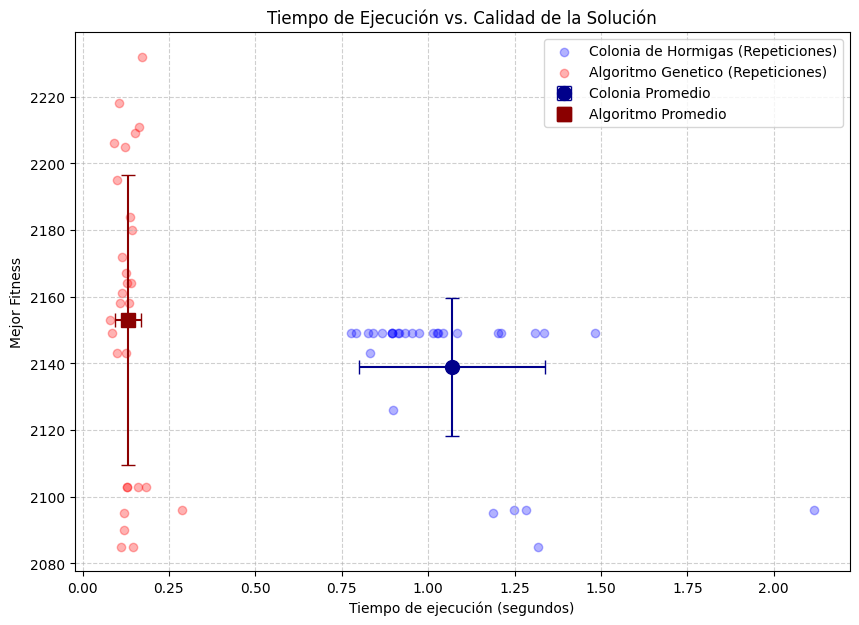

In [90]:
# listas para almacenar (Tiempo, Fitness)
data_colonia = []
data_ag = []

for i in range(len(resultados_colonia)):
    data_colonia.append((tiempos_colonia[i], resultados_colonia[i]))
    data_ag.append((tiempos_ag[i], resultados_ag[i]))

data_colonia = np.array(data_colonia)
data_ag = np.array(data_ag)


plt.figure(figsize=(10, 7))

# puntos individuales 
plt.scatter(data_colonia[:, 0], data_colonia[:, 1], c='blue', alpha=0.3, label='Colonia de Hormigas (Repeticiones)')
plt.scatter(data_ag[:, 0], data_ag[:, 1], c='red', alpha=0.3, label='Algoritmo Genetico (Repeticiones)')

# promedio y desvío Estándar
mean_colonia = np.mean(data_colonia, axis=0)
std_colonia = np.std(data_colonia, axis=0)
mean_ag = np.mean(data_ag, axis=0)
std_ag = np.std(data_ag, axis=0)

# barra de error para Colonia
plt.errorbar(mean_colonia[0], mean_colonia[1], xerr=std_colonia[0], yerr=std_colonia[1], fmt='o', color='darkblue', markersize=10, capsize=5, label='Colonia Promedio')

# barra de error para Algoritmo
plt.errorbar(mean_ag[0], mean_ag[1], xerr=std_ag[0], yerr=std_ag[1], fmt='s', color='darkred', markersize=10, capsize=5, label='Algoritmo Promedio')

plt.title('Tiempo de Ejecución vs. Calidad de la Solución')
plt.xlabel('Tiempo de ejecución (segundos)')
plt.ylabel('Mejor Fitness')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()